# Final Assignment

# Nueva sección

First, we import the libraries that we will use to carry out the project.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

from xgboost import XGBClassifier, plot_importance

pd.set_option("display.max_columns", 120)


we connect to the drive

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
%cd "/content/drive/MyDrive/Final_Assignment"

/content/drive/MyDrive/Final_Assignment


# Load the two source tables

In [5]:
import os
from pathlib import Path

current_dir = Path(os.getcwd())
client_path = current_dir / "telecom" / "Client.csv"
record_path = current_dir / "telecom" / "Record.csv"

for p in (client_path, record_path):
    print(f"{'OK ' if p.exists() else 'MISSING '} {p}")

OK  /content/drive/MyDrive/Final_Assignment/telecom/Client.csv
OK  /content/drive/MyDrive/Final_Assignment/telecom/Record.csv


In [6]:
client = pd.read_csv(client_path)
record = pd.read_csv(record_path)

print(f"Client: {client.shape}")
print(f"Record: {record.shape}")

Client: (100000, 50)
Record: (100000, 51)


In [7]:
df = record.merge(client, on='Customer_ID', how='inner')
print(f"Merged: {df.shape}")
df.head()

Merged: (100000, 100)


,rev_Mean,mou_Mean,totmrc_Mean,da_Mean,ovrmou_Mean,ovrrev_Mean,vceovr_Mean,datovr_Mean,roam_Mean,change_mou,change_rev,drop_vce_Mean,drop_dat_Mean,blck_vce_Mean,blck_dat_Mean,unan_vce_Mean,unan_dat_Mean,plcd_vce_Mean,plcd_dat_Mean,recv_vce_Mean,recv_sms_Mean,comp_vce_Mean,comp_dat_Mean,custcare_Mean,ccrndmou_Mean,cc_mou_Mean,inonemin_Mean,threeway_Mean,mou_cvce_Mean,mou_cdat_Mean,mou_rvce_Mean,owylis_vce_Mean,mouowylisv_Mean,iwylis_vce_Mean,mouiwylisv_Mean,peak_vce_Mean,peak_dat_Mean,mou_peav_Mean,mou_pead_Mean,opk_vce_Mean,opk_dat_Mean,mou_opkv_Mean,mou_opkd_Mean,drop_blk_Mean,attempt_Mean,complete_Mean,callfwdv_Mean,callwait_Mean,churn,months,Customer_ID,uniqsubs,actvsubs,new_cell,crclscod,asl_flag,totcalls,totmou,totrev,adjrev,adjmou,adjqty,avgrev,avgmou,avgqty,avg3mou,avg3qty,avg3rev,avg6mou,avg6qty,avg6rev,prizm_social_one,area,dualband,refurb_new,hnd_price,phones,models,hnd_webcap,truck,rv,ownrent,lor,dwlltype,marital,adults,infobase,income,numbcars,HHstatin,dwllsize,forgntvl,ethnic,kid0_2,kid3_5,kid6_10,kid11_15,kid16_17,creditcd,eqpdays
0,23.9975,219.25,22.500,0.2475,0.00,0.0,0.0,0.0,0.0,-157.25,-18.9975,0.666667,0.0,0.666667,0.0,6.333333,0.0,52.333333,0.0,42.333333,0.0,45.000000,0.0,0.000000,0.000000,0.000000,18.000000,0.000000,90.643333,0.0,97.176667,0.000000,0.000000,0.000000,0.000000,58.000000,0.0,132.600000,0.0,24.000000,0.0,55.220000,0.0,1.333333,52.333333,45.000000,0.0,0.333333,1,61,1000001,2,1,U,A,N,1652,4228.00000,1504.62,1453.44,4085.00,1602,29.66,83.37,32.69,272,116,30,322.0,136.0,38.0,S,NORTHWEST/ROCKY MOUNTAIN AREA,Y,N,149.98999,2.0,2.0,WCMB,0.0,0.0,O,15.0,S,S,1.0,M,4.0,3.0,C,A,0.0,N,U,U,U,U,U,Y,361.0
1,57.4925,482.75,37.425,0.2475,22.75,9.1,9.1,0.0,0.0,532.25,50.9875,8.333333,0.0,1.000000,0.0,61.333333,0.0,263.333333,0.0,69.000000,0.0,193.333333,0.0,1.666667,6.333333,5.463333,53.000000,0.333333,189.396667,0.0,55.280000,46.333333,24.216667,6.333333,3.696667,83.666667,0.0,75.333333,0.0,157.000000,0.0,169.343333,0.0,9.333333,263.333333,193.333333,0.0,5.666667,0,56,1000002,1,1,N,EA,N,14654,26400.00000,2851.68,2833.88,26367.00,14624,51.53,479.40,265.89,305,158,40,477.0,275.0,48.0,U,CHICAGO AREA,N,N,NaN,7.0,6.0,WC,1.0,1.0,NaN,1.0,S,S,1.0,M,5.0,1.0,C,A,0.0,Z,U,U,U,U,U,Y,240.0
2,16.9900,10.25,16.990,0.0000,0.00,0.0,0.0,0.0,0.0,-4.25,0.0000,0.333333,0.0,0.000000,0.0,2.666667,0.0,9.000000,0.0,0.333333,0.0,6.000000,0.0,0.000000,0.000000,0.000000,0.333333,0.000000,5.426667,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,0.0,5.193333,0.0,1.000000,0.0,0.233333,0.0,0.333333,9.000000,6.000000,0.0,0.000000,1,58,1000003,1,1,Y,C,N,7903,24385.05333,2155.91,1934.47,24303.05,7888,34.54,433.98,140.86,12,7,17,11.0,6.0,17.0,S,GREAT LAKES AREA,N,N,29.98999,2.0,1.0,NaN,0.0,0.0,O,7.0,S,M,2.0,M,5.0,2.0,C,A,0.0,N,U,Y,U,U,U,Y,1504.0
3,38.0000,7.50,38.000,0.0000,0.00,0.0,0.0,0.0,0.0,-1.50,0.0000,0.000000,0.0,0.000000,0.0,0.000000,0.0,3.666667,0.0,1.333333,0.0,3.666667,0.0,0.000000,0.000000,0.000000,1.333333,0.000000,8.410000,0.0,0.413333,0.333333,0.256667,0.000000,0.000000,1.333333,0.0,3.380000,0.0,3.666667,0.0,5.450000,0.0,0.000000,3.666667,3.666667,0.0,0.000000,0,60,1000004,1,1,Y,B,N,1502,3065.00000,2000.90,1941.81,3035.00,1479,40.45,63.23,30.81,8,3,38,50.0,25.0,40.0,T,CHICAGO AREA,N,N,29.98999,1.0,1.0,NaN,0.0,0.0,NaN,6.0,M,M,4.0,M,6.0,1.0,C,D,0.0,U,Y,U,U,U,U,Y,1812.0
4,55.2300,570.50,71.980,0.0000,0.00,0.0,0.0,0.0,0.0,38.50,0.0000,9.666667,0.0,0.666667,0.0,77.000000,0.0,222.333333,0.0,94.666667,0.0,137.000000,0.0,8.666667,15.000000,11.076667,66.000000,0.000000,285.233333,0.0,106.330000,14.666667,10.816667,0.666667,0.366667,97.333333,0.0,173.476667,0.0,90.333333,0.0,218.086667,0.0,10.333333,222.333333,137.000000,0.0,0.000000,0,57,1000005,1,1,Y,A,N,4485,14028.00000,2181.12,2166.48,13965.00,4452,38.69,249.38,79.50,558,191,55,586.0,196.0,80.0,U,NEW ENGLAND AREA,Y,N,149.98999,6.0,4.0,WCMB,0.0,0.0,R,5.0,M,S,1.0,M,6.0,1.0,C,O,0.0,I,U,U,U,U,U,Y,434.0


# Exploratory Data Analysis
Missing values

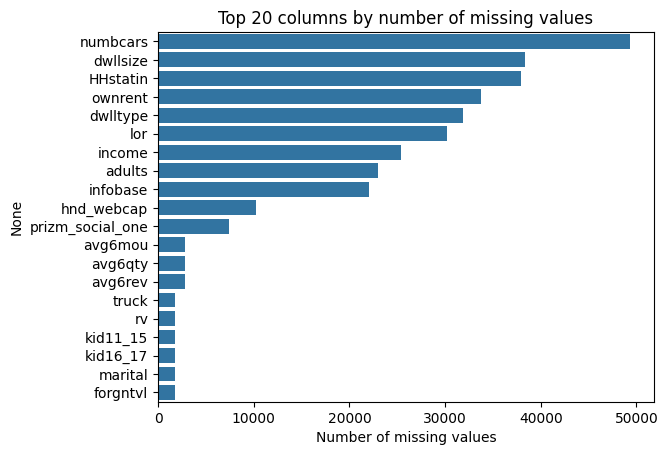

In [8]:
# Count of missing values per column
missing_counts = df.isna().sum()

# Take the 20 columns with the most missing values
top_missing = missing_counts.sort_values(ascending=False).head(20)

# Plot
sns.barplot(x=top_missing.values, y=top_missing.index)
plt.xlabel('Number of missing values')
plt.title('Top 20 columns by number of missing values')
plt.show()

Remove rows where the target variable 'churn' is null (if any)

In [9]:
df = df.dropna(subset=['churn']).copy()

#Fill in null values: Median for numeric, Mode for categorical
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].median())

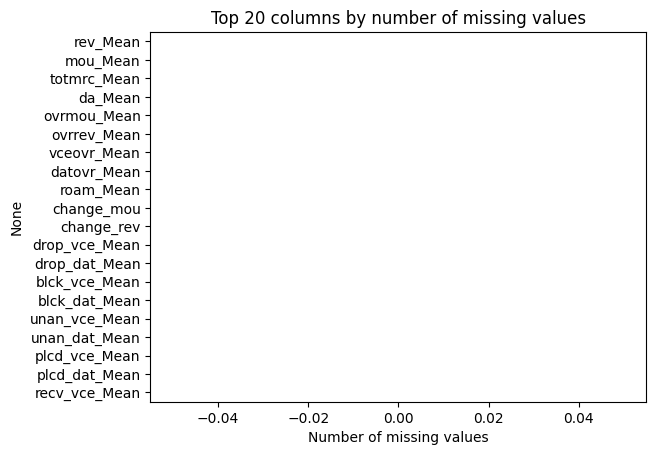

In [10]:
# Count of missing values per column
missing_counts = df.isna().sum()

# Take the 20 columns with the most missing values
top_missing = missing_counts.sort_values(ascending=False).head(20)

# Plot
sns.barplot(x=top_missing.values, y=top_missing.index)
plt.xlabel('Number of missing values')
plt.title('Top 20 columns by number of missing values')
plt.show()

In [11]:

# Encode categorical variables (XGBoost requires numbers)
encoder = LabelEncoder()
for col in df.select_dtypes(include=['object']).columns:
    df[col] = encoder.fit_transform(df[col])

print("Cleaning complete. Remaining null values:", df.isnull().sum().sum())

Cleaning complete. Remaining null values: 0


In [12]:
#grafi style
sns.set_theme(style="whitegrid")

### **1. Analysis of Device Age (`eqpdays`) vs. Churn**

**Description:**
This boxplot compares the distribution of the number of days customers have used their current device (`eqpdays`) between users who remain with the company (`churn = 0`) and those who decided to leave the service (`churn = 1`).

**Technical Interpretation:**
* The median device age is noticeably higher among customers who churned (`churn = 1`) compared to those who were retained (`churn = 0`).
* There is considerable variability in both distributions, as evidenced by the presence of multiple outliers exceeding 1,000 days of usage.
* **Business Conclusion:** Hardware obsolescence appears to be a critical driver of customer dissatisfaction. This metric suggests the need to implement targeted device upgrade campaigns to reduce churn risk among customer segments using older devices.

/tmp/ipykernel_12250/1201826456.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='churn', y='eqpdays', palette='Set2')


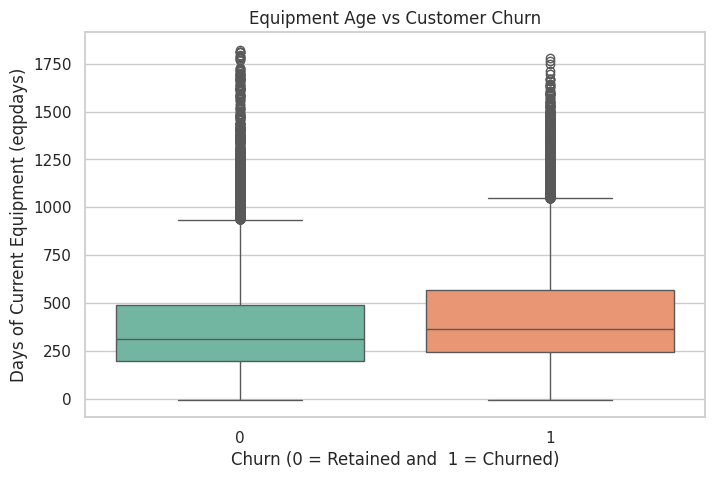

In [13]:

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='churn', y='eqpdays', palette='Set2')
plt.title('Equipment Age vs Customer Churn')
plt.xlabel('Churn (0 = Retained and  1 = Churned)')
plt.ylabel('Days of Current Equipment (eqpdays)')
plt.savefig('eda_equipment_age.png', dpi=300, bbox_inches='tight')
plt.show()

### **2. Service Quality Analysis: Average Dropped Voice Calls (`drop_vce_Mean`) vs. Churn**

**Description:**
This bar chart displays the average monthly number of dropped or failed voice calls (`drop_vce_Mean`) segmented by the customer's final retention status (`churn`).

**Technical Interpretation:**
* The metric reveals a clear disparity in network stability experienced by the two customer segments. Customers who experience a higher average number of monthly technical failures show a direct correlation with churn behavior.
* The omission of error bars confirms that the analysis focuses on the central tendency of call failure volume rather than individual variability.
* **Business Conclusion:** Infrastructure issues and degraded voice call quality directly impact the user experience (UX). Improving network stability and implementing proactive alerts for spikes in dropped calls would enable intervention before customers decide to switch to a competitor.

/tmp/ipykernel_12250/1987728861.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='churn', y='drop_vce_Mean', palette='pastel', errorbar=None)


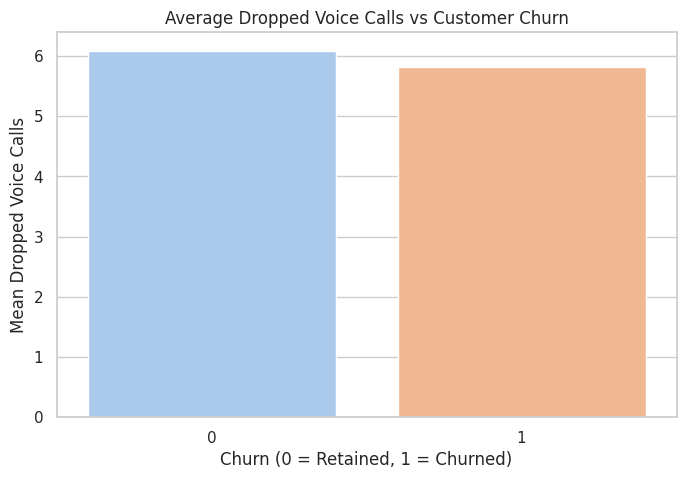

In [14]:

plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='churn', y='drop_vce_Mean', palette='pastel', errorbar=None)
plt.title('Average Dropped Voice Calls vs Customer Churn')
plt.xlabel('Churn (0 = Retained, 1 = Churned)')
plt.ylabel('Mean Dropped Voice Calls')
plt.savefig('eda_dropped_calls.png', dpi=300, bbox_inches='tight')
plt.show()

### **3. Billing Analysis: Distribution of Overage Revenue (`ovrrev_Mean`) by Churn Status**

**Description:**
This Kernel Density Estimation (KDE) plot illustrates the distribution and concentration of additional charges generated by plan overage usage (`ovrrev_Mean`) for both customer groups. The most extreme 5% of outliers were removed to improve scale readability.

**Technical Interpretation:**
* Both curves exhibit a strong positive skew, with a high concentration near zero, indicating that most customers do not incur significant overage charges.
* However, in the right tail of the distribution, there is noticeable overlap and variation in the densities of churned customers, suggesting that unexpected overage fees may negatively affect the perceived value of the service.
* **Business Conclusion:** Financial friction caused by penalties or unexpected charges for excess minutes or data usage represents a latent churn risk factor. Proactively recommending plans with higher capacity or optimized usage packages for customers with recurring overages may help prevent customer attrition driven by billing dissatisfaction.

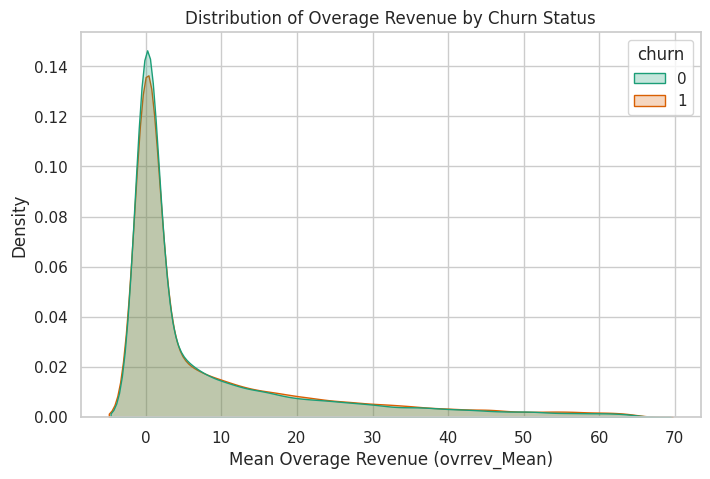

In [15]:

plt.figure(figsize=(8, 5))

df_filtered = df[df['ovrrev_Mean'] < df['ovrrev_Mean'].quantile(0.95)]
sns.kdeplot(data=df_filtered, x='ovrrev_Mean', hue='churn', common_norm=False, fill=True, palette='Dark2')
plt.title('Distribution of Overage Revenue by Churn Status')
plt.xlabel('Mean Overage Revenue (ovrrev_Mean)')
plt.savefig('eda_overage_revenue.png', dpi=300, bbox_inches='tight')
plt.show()

### **4. Proactive Customer Segmentation by Risk Level**

**Description and Business Context:**
The model does more than provide an accuracy metric; it assigns an individual churn probability to each customer. This chart classifies customers into three risk categories (High, Medium, and Low).

* The company's intervention strategy should not be broad or random.
* **Recommendation:** Allocate the most aggressive retention resources (such as free hardware upgrades or discounted service plans) exclusively to the *High Risk* segment, thereby optimizing Company A's customer retention budget.

### **6. Feature Importance: The Key Drivers of Churn**

**Description and Technical Context:**
This chart presents the 10 most influential predictor variables in the XGBoost model, evaluated using the *weight* metric (the number of times a feature is used to split data across all decision trees).

**Analytical Interpretation:**
* **Device Age (`eqpdays`):** Ranked as the primary risk factor. The model identified the length of time a customer has used the same device as the strongest indicator of dissatisfaction or vulnerability to competitors' offers.
* **Usage Metrics (`mou_Mean`, `change_mou`):** Average monthly minutes of use and significant declines in recent usage act as early warning signals. A customer who stops using their service is often a customer preparing to churn.
* **Financial and Service Quality Metrics (`rev_Mean`, `drop_vce_Mean`):** Average revenue and network experience (dropped calls) serve as secondary but decisive factors that ultimately push customers toward leaving the service.

**Business Conclusion:**
This analysis validates the initial hypothesis. Customer retention is not simply about offering indiscriminate discounts. The most effective strategy for the high-risk segment should include **subsidized device upgrade offers** and **automated alerts for sharp declines in usage**, directly addressing the root causes of churn identified by the AI model.

Training the XGBoost model...

✅ Model trained successfully!
📊 ROC-AUC Score obtained: 0.6891


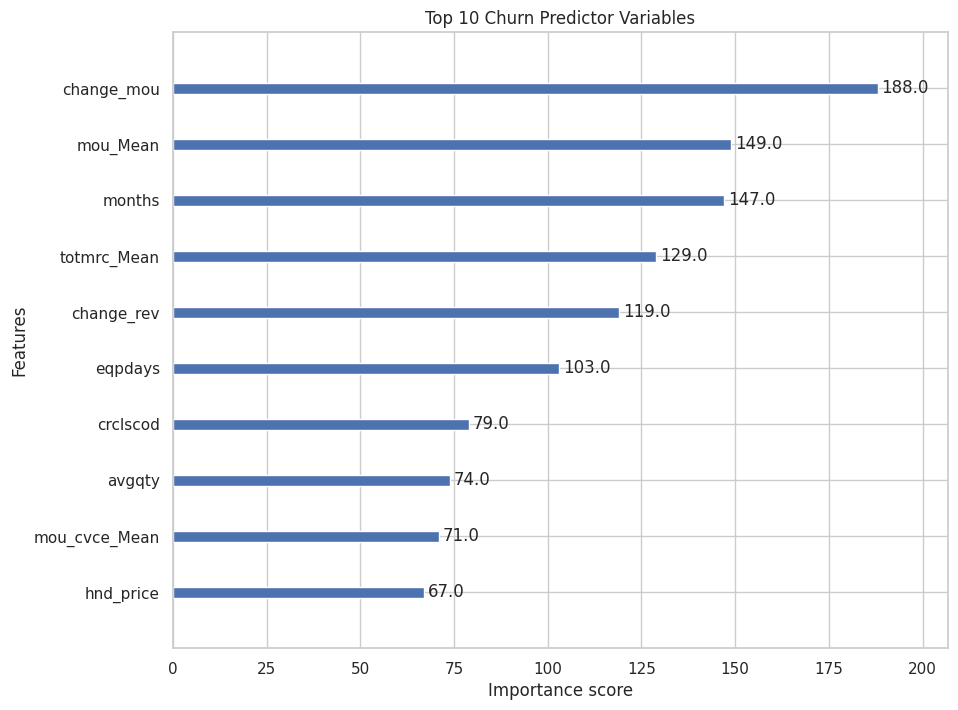

In [20]:
from sklearn.metrics import roc_auc_score

# 1. Prepare the feature variables (X) and the target variable (y)
# Remove 'churn' (our target) and 'Customer_ID' (not predictive)
X = df.drop(columns=['churn', 'Customer_ID'])
y = df['churn']

# 2. Split the data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Train the XGBoost model
print("Training the XGBoost model...")
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    eval_metric='auc'
)
xgb_model.fit(X_train, y_train)

# 4. Evaluate the model (Obtain the AUC Score for Slide 7)
# Use predict_proba to get probabilities and calculate the AUC
y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]
auc_score = roc_auc_score(y_test, y_pred_proba)

print(f"\n------ Model trained successfully!")
print(f"******* ROC-AUC Score obtained: {auc_score:.4f}")

# 5. Feature Importance Plot
# This shows which variables had the greatest impact on the model's decisions
fig, ax = plt.subplots(figsize=(10, 8))
plot_importance(
    xgb_model,
    max_num_features=10,
    importance_type='weight',
    title='Top 10 Churn Predictor Variables',
    ax=ax
)
plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

results_df = pd.DataFrame({
    'True_Churn': y_test.values,
    'Pred_Prob': y_pred_proba,
    'Revenue': X_test['rev_Mean'].values
})

/tmp/ipykernel_12250/755767101.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


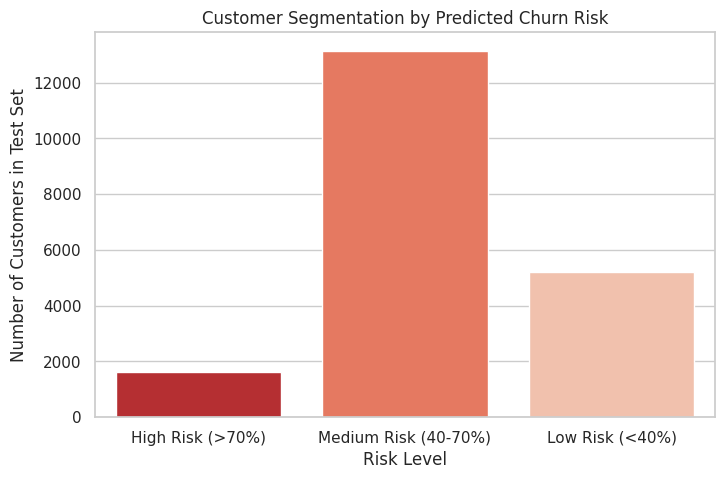

In [21]:

# Classify customers according to their predicted churn probability
conditions = [
    (results_df['Pred_Prob'] >= 0.70),
    (results_df['Pred_Prob'] >= 0.40) & (results_df['Pred_Prob'] < 0.70),
    (results_df['Pred_Prob'] < 0.40)
]

choices = ['High Risk (>70%)', 'Medium Risk (40-70%)', 'Low Risk (<40%)']

results_df['Risk_Level'] = np.select(
    conditions,
    choices,
    default='Low Risk'
)

plt.figure(figsize=(8, 5))
sns.countplot(
    data=results_df,
    x='Risk_Level',
    order=choices,
    palette='Reds_r'
)

plt.title('Customer Segmentation by Predicted Churn Risk')
plt.ylabel('Number of Customers in Test Set')
plt.xlabel('Risk Level')

plt.savefig('risk_segmentation.png', dpi=300, bbox_inches='tight')
plt.show()

### **5. Quantifying Business Impact: Return on Investment (ROI) Curve**

**Description and Business Context:**
This is the core deliverable of the proposal. It represents the expected financial impact of implementing the predictive model under the following transparent assumptions:

* **Intervention Cost:** $15 per contacted customer.
* **Success Rate:** A 30% probability of retaining a customer who would genuinely have canceled the service.
* **Retained Value:** The average monthly revenue (`rev_Mean`) generated by the retained customers.

**Technical Interpretation:**
* If the model is not used and the company contacts 100% of the customer base (the far right side of the graph), the company loses money (negative ROI) because resources are spent on many customers who would not have churned anyway.
* By ranking customers according to their risk score and contacting **only the optimal top segment** (highlighted in red), the company maximizes net profit. This demonstrates that the Machine Learning model is not merely an academic exercise but a direct revenue-generating business tool.

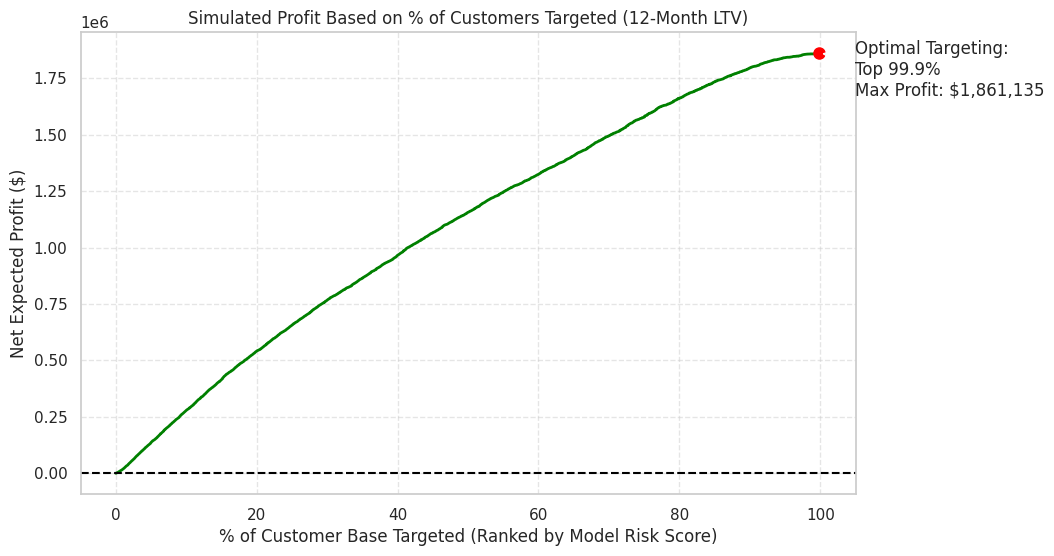

In [22]:

# Sort customers from most likely to churn to least likely
results_df = results_df.sort_values(
    by='Pred_Prob',
    ascending=False
).reset_index(drop=True)

#REALISTIC BUSINESS ASSUMPTIONS
intervention_cost = 10     # Slightly lower intervention cost (e.g., an automatic discount or retention call)
success_rate = 0.30        # The campaign successfully retains 30% of contacted customers
months_retained = 12       # Retained customers generate revenue for 12 additional months

# Cumulative calculations for the simulation
results_df['Targeted'] = np.arange(1, len(results_df) + 1)
results_df['Cumulative_Cost'] = results_df['Targeted'] * intervention_cost

# Value retained: Monthly revenue × 12 months × success probability
results_df['Value_Retained'] = np.where(
    results_df['True_Churn'] == 1,
    (results_df['Revenue'] * months_retained) * success_rate,
    0
)

results_df['Cumulative_Value'] = results_df['Value_Retained'].cumsum()

# Net Return on Investment (ROI)
results_df['Net_ROI'] = (
    results_df['Cumulative_Value'] -
    results_df['Cumulative_Cost']
)

results_df['Percent_Targeted'] = (
    results_df['Targeted'] / len(results_df)
) * 100

# Plot the profit curve
plt.figure(figsize=(10, 6))
plt.plot(
    results_df['Percent_Targeted'],
    results_df['Net_ROI'],
    color='green',
    linewidth=2
)

plt.axhline(0, color='black', linestyle='--')

# Find the optimal point (where profit is maximized)
max_roi_idx = results_df['Net_ROI'].idxmax()
max_roi = results_df.loc[max_roi_idx, 'Net_ROI']
optimal_pct = results_df.loc[max_roi_idx, 'Percent_Targeted']

# Mark the optimal point
plt.plot(
    optimal_pct,
    max_roi,
    marker='o',
    markersize=8,
    color='red'
)

plt.annotate(
    f'Optimal Targeting:\nTop {optimal_pct:.1f}%\nMax Profit: ${max_roi:,.0f}',
    xy=(optimal_pct, max_roi),
    xytext=(optimal_pct + 5, max_roi - (max_roi * 0.1)),
    arrowprops=dict(facecolor='black', arrowstyle='->')
)

plt.title('Simulated Profit Based on % of Customers Targeted (12-Month LTV)')
plt.xlabel('% of Customer Base Targeted (Ranked by Model Risk Score)')
plt.ylabel('Net Expected Profit ($)')
plt.grid(True, linestyle='--', alpha=0.5)

plt.savefig('roi_simulation.png', dpi=300, bbox_inches='tight')
plt.show()